# 4 . Conformal Prediction - calibracion de modelos

> **Tipo de ML:** supervisado . clase: calor+frio  
> **Proposito:** aplicar split conformal prediction y calibracion isotonica
> sobre los modelos ya entrenados (RF_frio, XGBoost_calor).

## Preguntas
1. Que tan bien calibradas estan las probabilidades actuales?
2. Mejora la calibracion con isotonic regression?
3. Mejora Rec_riesgo al aplicar t1/t2 sobre probas calibradas?
4. Vale la pena integrarlo?


In [1]:
import sys
sys.path.insert(0, "..")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    confusion_matrix, classification_report, brier_score_loss,
    ConfusionMatrixDisplay,
)
from sklearn.model_selection import train_test_split
from sklearn.isotonic import IsotonicRegression

from climasafeai.utils.paths import PROCESSED_DATA_DIR, MODELS_DIR, ARTIFACTS_DIR
from climasafeai.models.predict_model import apply_class_thresholds, CLASS_THRESHOLDS_RECOMENDADOS

sns.set_style("whitegrid")
%matplotlib inline
print("Imports listos")


Imports listos


## 1. Cargar datos y modelos

In [2]:
DATA = {}
for clase in ("calor", "frio"):
    X_test = pd.read_csv(PROCESSED_DATA_DIR / f"X_test_{clase}.csv")
    y_test = pd.read_csv(PROCESSED_DATA_DIR / f"y_test_{clase}.csv").iloc[:, 0]
    scaler = joblib.load(ARTIFACTS_DIR / f"scaler_{clase}.joblib")
    feature_names = joblib.load(ARTIFACTS_DIR / f"feature_names_{clase}.joblib")
    X_test_scaled = scaler.transform(X_test[feature_names])
    DATA[clase] = {
        "X": X_test_scaled,
        "y": y_test.values,
    }
    print(f"{clase}: X={X_test_scaled.shape}, y={y_test.shape}")
    print(f"  clases: {np.bincount(y_test.values)}")


calor: X=(34470, 27), y=(34470,)
  clases: [30446  2044  1980]
frio: X=(34470, 23), y=(34470,)
  clases: [31379  1519  1572]


In [3]:
MODELS = {}
for clase, fname in [("calor", "XGBoost"), ("frio", "RandomForest")]:
    model = joblib.load(MODELS_DIR / f"{fname}_{clase}.joblib")
    MODELS[clase] = model
    print(f"{fname}_{clase}: {type(model).__name__}")


XGBoost_calor: XGBClassifier
RandomForest_frio: RandomForestClassifier


## 2. Baseline: calibracion actual

Brier score + reliability diagrams para PELIGRO (clase 2).


  Brier Score (PELIGRO) - menor es mejor

  XGBoost_calor:
    Brier original: 0.057440

  RandomForest_frio:
    Brier original: 0.219871


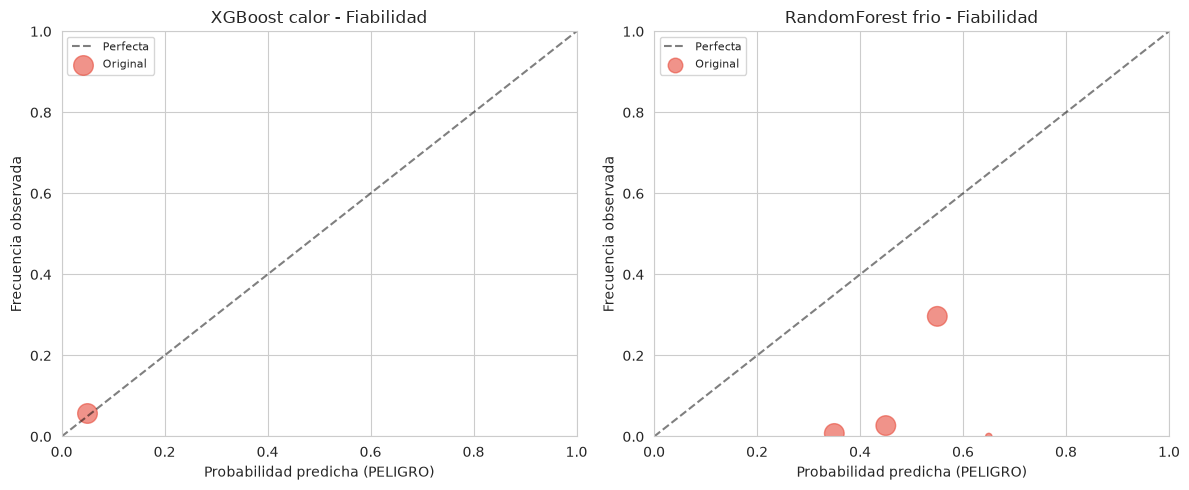

In [4]:
def reliability_curve(y_true, proba_cls, n_bins=10):
    bin_edges = np.linspace(0, 1, n_bins + 1)
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    observed = np.zeros(n_bins)
    predicted = np.zeros(n_bins)
    counts = np.zeros(n_bins)
    for i in range(n_bins):
        mask = (proba_cls >= bin_edges[i]) & (proba_cls < bin_edges[i + 1])
        counts[i] = mask.sum()
        if counts[i] > 0:
            predicted[i] = proba_cls[mask].mean()
            observed[i] = y_true[mask].mean()
    return bin_centers, predicted, observed, counts

def plot_reliability(probas_dict, y_bin, title, ax):
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfecta")
    colors = ["#e74c3c", "#3498db", "#2ecc71"]
    for (label, proba), color in zip(probas_dict.items(), colors):
        centers, pred, obs, counts = reliability_curve(y_bin, proba)
        mask = counts > 0
        sizes = np.clip(30 * np.sqrt(counts[mask] + 1) / 2, 10, 200)
        ax.scatter(centers[mask], obs[mask], c=color, label=label, s=sizes, alpha=0.6)
    ax.set_xlabel("Probabilidad predicha (PELIGRO)")
    ax.set_ylabel("Frecuencia observada")
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
print("=" * 60)
print("  Brier Score (PELIGRO) - menor es mejor")
print("=" * 60)

for idx, clase in enumerate(("calor", "frio")):
    model = MODELS[clase]
    X = DATA[clase]["X"]
    y = DATA[clase]["y"]
    proba = model.predict_proba(X)
    y_bin = (y == 2).astype(int)
    brier_orig = brier_score_loss(y_bin, proba[:, 2])
    modelo_nombre = "XGBoost" if clase == "calor" else "RandomForest"
    print(f"\n  {modelo_nombre}_{clase}:")
    print(f"    Brier original: {brier_orig:.6f}")
    plot_reliability(
        {"Original": proba[:, 2]},
        y_bin,
        f"{modelo_nombre} {clase} - Fiabilidad",
        axes[idx],
    )

plt.tight_layout()
plt.savefig("../reports/figures/reliability_baseline.png", dpi=150, bbox_inches="tight")
plt.show()


## 3. Split conformal prediction

Dividimos test en calibracion (50%) y evaluacion (50%).
Nonconformity score: 1 - P(y_true|x).
Cobertura deseada: 90%.



  XGBoost_calor
  qhat (alpha=0.1):       1.0000
  Cobertura real:           0.8993 (deseada: 0.9000)
  Tamano medio de set:      1.142
  Set size = 1 (cierto):    14787/17235
  Set size = 2 (incierto):  2448/17235
  Set size = 3 (muy incierto): 0/17235

  Rec_riesgo (argmax):    0.0000
  Rec_riesgo (t1/t2):     0.0000
  Rec_riesgo (conformal): 0.0000

  RandomForest_frio
  qhat (alpha=0.1):       0.8984
  Cobertura real:           0.8992 (deseada: 0.9000)
  Tamano medio de set:      2.837
  Set size = 1 (cierto):    0/17235
  Set size = 2 (incierto):  2802/17235
  Set size = 3 (muy incierto): 14433/17235

  Rec_riesgo (argmax):    0.5088
  Rec_riesgo (t1/t2):     0.4981
  Rec_riesgo (conformal): 0.5088

Conformal prediction aplicada


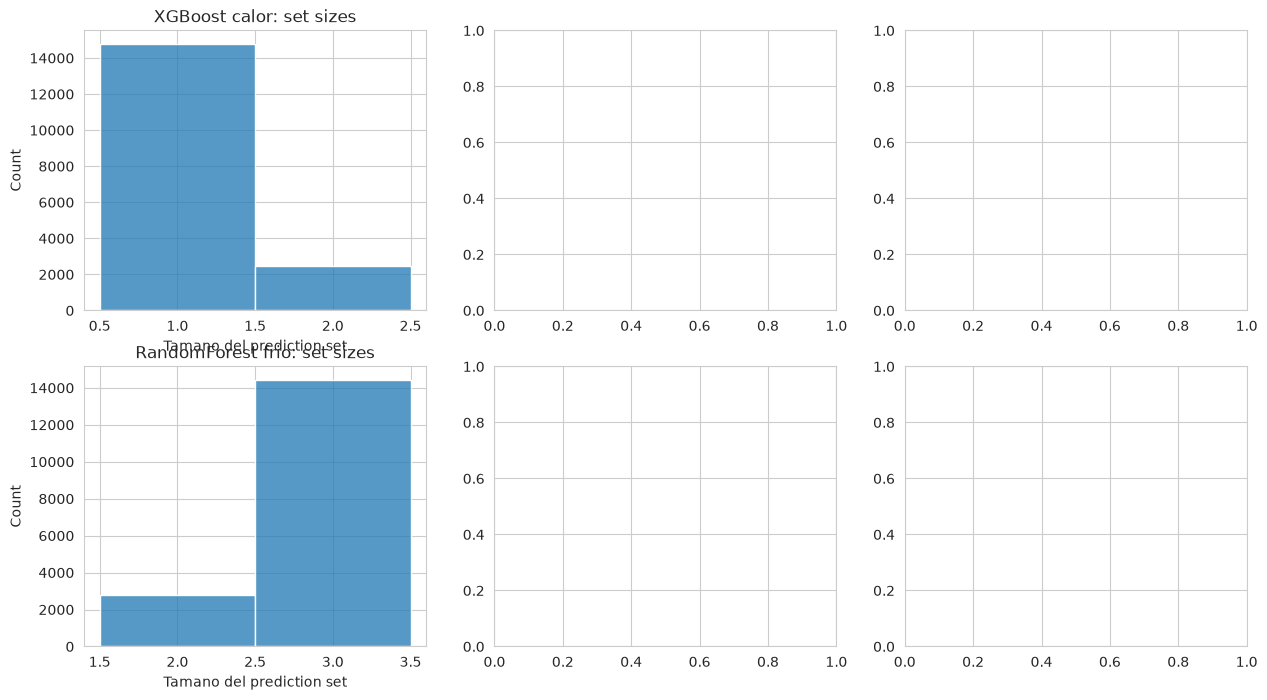

In [5]:
ALPHA = 0.1
RES_CONF = {}
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, clase in enumerate(("calor", "frio")):
    model = MODELS[clase]
    X = DATA[clase]["X"]
    y = DATA[clase]["y"]
    proba = model.predict_proba(X)
    n_classes = proba.shape[1]

    X_cal, X_eval, y_cal, y_eval, proba_cal, proba_eval = train_test_split(
        X, y, proba, test_size=0.5, random_state=42, stratify=y
    )

    n_cal = len(y_cal)
    scores_cal = np.array([1.0 - proba_cal[i, y_cal[i]] for i in range(n_cal)])
    qhat = np.quantile(scores_cal, np.ceil((n_cal + 1) * (1 - ALPHA)) / n_cal, method="higher")

    sets = []
    for i in range(len(proba_eval)):
        s = {c for c in range(n_classes) if 1.0 - proba_eval[i, c] <= qhat}
        sets.append(s)
    set_sizes = np.array([len(s) for s in sets])
    cobertura = np.mean([y_eval[i] in sets[i] for i in range(len(y_eval))])

    preds_conf = np.zeros(len(y_eval), dtype=int)
    for i, s in enumerate(sets):
        if len(s) == 0:
            preds_conf[i] = np.argmax(proba_eval[i])
        elif len(s) == 1:
            preds_conf[i] = next(iter(s))
        else:
            candidates = list(s)
            preds_conf[i] = candidates[np.argmax(proba_eval[i, candidates])]

    preds_argmax = np.argmax(proba_eval, axis=1)
    thresh = CLASS_THRESHOLDS_RECOMENDADOS[clase]
    preds_umbral = apply_class_thresholds(proba_eval, thresh["t1"], thresh["t2"])

    modelo_nombre = "XGBoost" if clase == "calor" else "RandomForest"
    print(f"\n{'='*60}")
    print(f"  {modelo_nombre}_{clase}")
    print(f"{'='*60}")
    print(f"  qhat (alpha={ALPHA}):       {qhat:.4f}")
    print(f"  Cobertura real:           {cobertura:.4f} (deseada: {1-ALPHA:.4f})")
    print(f"  Tamano medio de set:      {set_sizes.mean():.3f}")
    print(f"  Set size = 1 (cierto):    {(set_sizes == 1).sum()}/{len(set_sizes)}")
    print(f"  Set size = 2 (incierto):  {(set_sizes == 2).sum()}/{len(set_sizes)}")
    if n_classes == 3:
        print(f"  Set size = 3 (muy incierto): {(set_sizes == 3).sum()}/{len(set_sizes)}")

    risk_labels = [c for c in np.unique(y_eval) if c != 0]
    rec_a = recall_score(y_eval, preds_argmax, labels=risk_labels, average="macro", zero_division=0)
    rec_u = recall_score(y_eval, preds_umbral, labels=risk_labels, average="macro", zero_division=0)
    rec_c = recall_score(y_eval, preds_conf, labels=risk_labels, average="macro", zero_division=0)
    print(f"\n  Rec_riesgo (argmax):    {rec_a:.4f}")
    print(f"  Rec_riesgo (t1/t2):     {rec_u:.4f}")
    print(f"  Rec_riesgo (conformal): {rec_c:.4f}")

    RES_CONF[clase] = dict(qhat=qhat, cobertura=cobertura, set_size_mean=set_sizes.mean(),
                           preds_conf=preds_conf, y_eval=y_eval, proba_eval=proba_eval,
                           set_sizes=set_sizes)

    ax = axes[idx, 0]
    sns.histplot(set_sizes, discrete=True, ax=ax)
    ax.set_title(f"{modelo_nombre} {clase}: set sizes")
    ax.set_xlabel("Tamano del prediction set")

print("\nConformal prediction aplicada")


## 4. Calibracion con Isotonic Regression

Regresion isotonica sobre PELIGRO (clase 2).
Metodo de calibracion post-hoc mas comun.



  XGBoost_calor:
    Brier original:  0.057440
    Brier isotonic:  0.052997
    Mejora:          0.004442 (7.7%)
    Rec_riesgo (t1/t2 original):  0.0000
    Rec_riesgo (t1/t2 isotonic):  0.0000

  RandomForest_frio:
    Brier original:  0.219782
    Brier isotonic:  0.039211
    Mejora:          0.180570 (82.2%)
    Rec_riesgo (t1/t2 original):  0.4981
    Rec_riesgo (t1/t2 isotonic):  0.5145


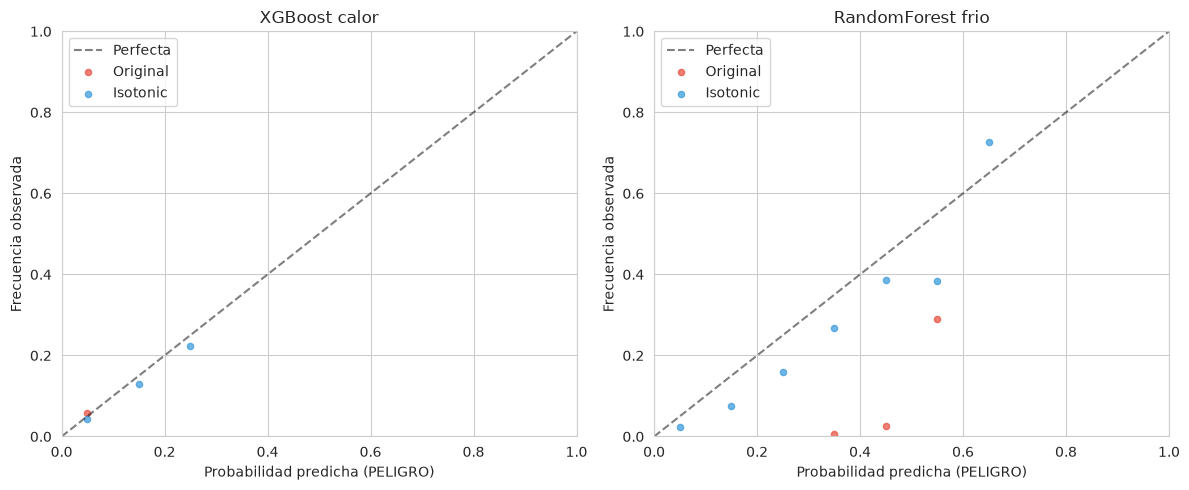


Isotonic regression aplicada


In [6]:
RES_ISO = {}
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for idx, clase in enumerate(("calor", "frio")):
    X = DATA[clase]["X"]
    y = DATA[clase]["y"]
    model = MODELS[clase]
    X_cal, X_eval, y_cal, y_eval = train_test_split(
        X, y, test_size=0.5, random_state=42, stratify=y
    )
    proba_eval = model.predict_proba(X_eval)
    proba_cal = model.predict_proba(X_cal)

    iso = IsotonicRegression(out_of_bounds="clip")
    iso.fit(proba_cal[:, 2], (y_cal == 2).astype(int))
    proba_p2_iso = iso.transform(proba_eval[:, 2])

    proba_iso = proba_eval.copy()
    proba_iso[:, 2] = proba_p2_iso
    proba_iso = proba_iso / proba_iso.sum(axis=1, keepdims=True)

    y_bin = (y_eval == 2).astype(int)
    brier_orig = brier_score_loss(y_bin, proba_eval[:, 2])
    brier_iso = brier_score_loss(y_bin, proba_iso[:, 2])

    modelo_nombre = "XGBoost" if clase == "calor" else "RandomForest"
    print(f"\n  {modelo_nombre}_{clase}:")
    print(f"    Brier original:  {brier_orig:.6f}")
    print(f"    Brier isotonic:  {brier_iso:.6f}")
    mejora_pct = (brier_orig - brier_iso) / brier_orig * 100
    print(f"    Mejora:          {brier_orig - brier_iso:.6f} ({mejora_pct:.1f}%)")

    thresh = CLASS_THRESHOLDS_RECOMENDADOS[clase]
    preds_iso = apply_class_thresholds(proba_iso, thresh["t1"], thresh["t2"])
    preds_orig = apply_class_thresholds(proba_eval, thresh["t1"], thresh["t2"])

    risk_labels = [c for c in np.unique(y_eval) if c != 0]
    rec_iso = recall_score(y_eval, preds_iso, labels=risk_labels, average="macro", zero_division=0)
    rec_orig = recall_score(y_eval, preds_orig, labels=risk_labels, average="macro", zero_division=0)
    print(f"    Rec_riesgo (t1/t2 original):  {rec_orig:.4f}")
    print(f"    Rec_riesgo (t1/t2 isotonic):  {rec_iso:.4f}")

    RES_ISO[clase] = dict(proba_iso=proba_iso, brier_orig=brier_orig, brier_iso=brier_iso,
                          rec_riesgo_orig=rec_orig, rec_riesgo_iso=rec_iso, preds_iso=preds_iso,
                          y_eval=y_eval, proba_eval=proba_eval)

    ax = axes[idx]
    ax.plot([0, 1], [0, 1], "k--", alpha=0.5, label="Perfecta")
    for label, proba_cls, color in [
        ("Original", proba_eval[:, 2], "#e74c3c"),
        ("Isotonic", proba_iso[:, 2], "#3498db"),
    ]:
        c, p, o, cnts = reliability_curve(y_bin, proba_cls)
        mask = cnts > 0
        ax.scatter(c[mask], o[mask], c=color, label=label, s=20, alpha=0.7)
    ax.set_title(f"{modelo_nombre} {clase}")
    ax.set_xlabel("Probabilidad predicha (PELIGRO)")
    ax.set_ylabel("Frecuencia observada")
    ax.legend()
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig("../reports/figures/reliability_isotonic.png", dpi=150, bbox_inches="tight")
plt.show()
print("\nIsotonic regression aplicada")


## 5. Matrices de confusion comparativas

Argmax vs. t1/t2 vs. Isotonic+t1/t2 vs. Conformal set.


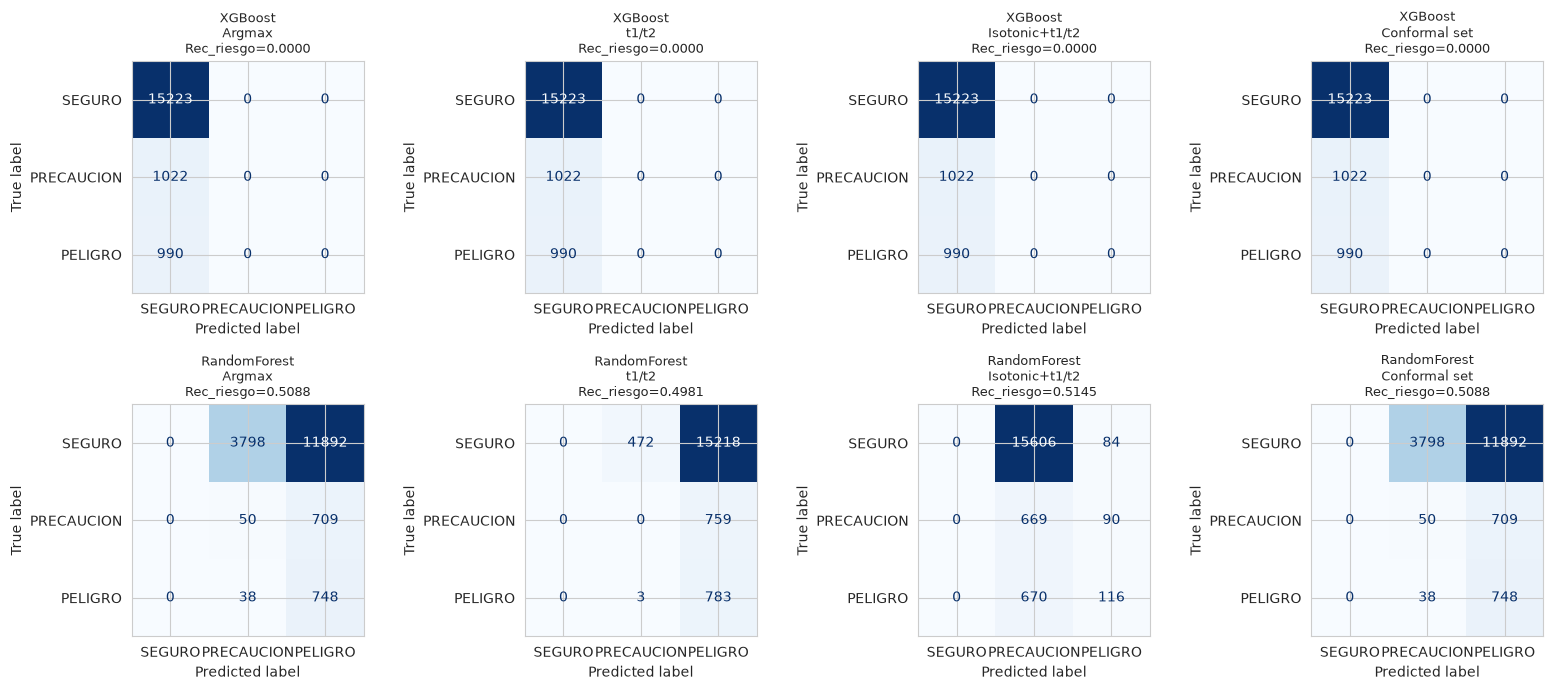

Matrices guardadas


In [7]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7))

for idx, clase in enumerate(("calor", "frio")):
    model = MODELS[clase]
    X = DATA[clase]["X"]
    y = DATA[clase]["y"]
    _, X_eval, _, y_eval = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)
    proba_eval = model.predict_proba(X_eval)

    preds_argmax = np.argmax(proba_eval, axis=1)
    thresh = CLASS_THRESHOLDS_RECOMENDADOS[clase]
    preds_umbral = apply_class_thresholds(proba_eval, thresh["t1"], thresh["t2"])
    preds_conf = RES_CONF[clase]["preds_conf"]
    preds_iso = RES_ISO[clase]["preds_iso"]

    modelo_nombre = "XGBoost" if clase == "calor" else "RandomForest"
    data = [
        (f"{modelo_nombre}\nArgmax", preds_argmax),
        (f"{modelo_nombre}\nt1/t2", preds_umbral),
        (f"{modelo_nombre}\nIsotonic+t1/t2", preds_iso),
        (f"{modelo_nombre}\nConformal set", preds_conf),
    ]
    for j, (title, preds) in enumerate(data):
        ax = axes[idx, j]
        ConfusionMatrixDisplay.from_predictions(y_eval, preds, ax=ax,
            display_labels=["SEGURO", "PRECAUCION", "PELIGRO"],
            colorbar=False, cmap="Blues")
        risk_labels = [c for c in np.unique(y_eval) if c != 0]
        rec = recall_score(y_eval, preds, labels=risk_labels, average="macro", zero_division=0)
        ax.set_title(f"{title}\nRec_riesgo={rec:.4f}", fontsize=9)

plt.tight_layout()
plt.savefig("../reports/figures/conf_matrix_comparativa.png", dpi=150, bbox_inches="tight")
plt.show()
print("Matrices guardadas")


## 6. Error de calibracion por decil

Error (predicho - observado) en cada decil de probabilidad PELIGRO.


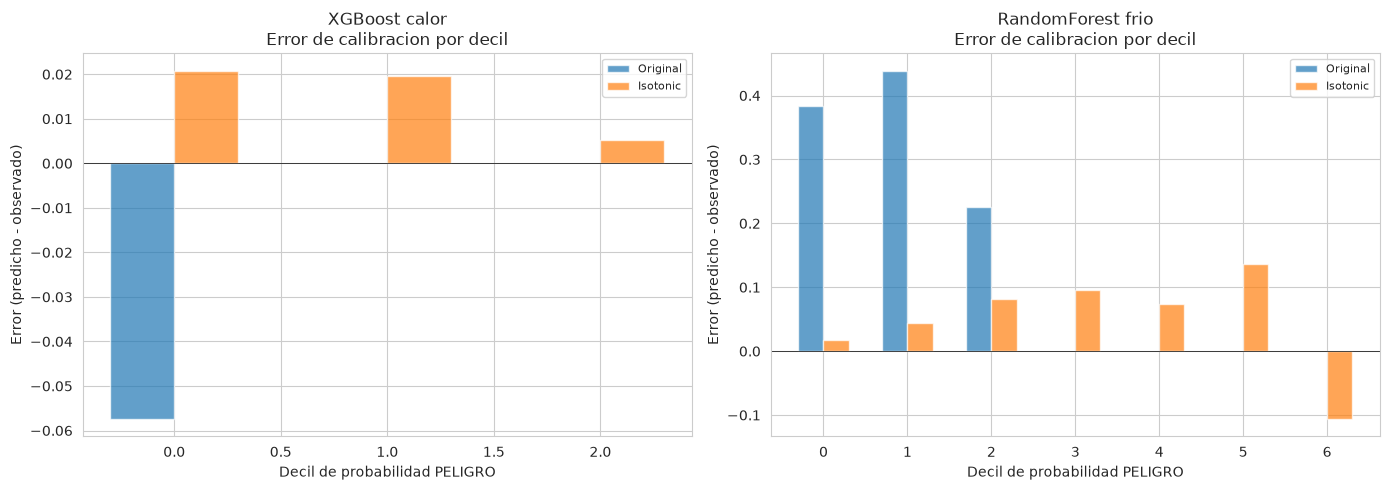

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for idx, clase in enumerate(("calor", "frio")):
    y_eval = RES_ISO[clase]["y_eval"]
    proba_eval = RES_ISO[clase]["proba_eval"]
    proba_iso = RES_ISO[clase]["proba_iso"]
    y_bin = (y_eval == 2).astype(int)
    modelo_nombre = "XGBoost" if clase == "calor" else "RandomForest"

    deciles = np.linspace(0, 1, 11)
    errors_orig = []
    errors_iso = []
    for i in range(10):
        mask = (proba_eval[:, 2] >= deciles[i]) & (proba_eval[:, 2] < deciles[i+1])
        if mask.sum() > 0:
            obs = y_bin[mask].mean()
            errors_orig.append(proba_eval[mask, 2].mean() - obs)
        mask_iso = (proba_iso[:, 2] >= deciles[i]) & (proba_iso[:, 2] < deciles[i+1])
        if mask_iso.sum() > 0:
            obs = y_bin[mask_iso].mean()
            errors_iso.append(proba_iso[mask_iso, 2].mean() - obs)

    ax = axes[idx]
    ax.bar(np.arange(len(errors_orig)) - 0.15, errors_orig, width=0.3, label="Original", alpha=0.7)
    ax.bar(np.arange(len(errors_iso)) + 0.15, errors_iso, width=0.3, label="Isotonic", alpha=0.7)
    ax.axhline(0, color="k", linewidth=0.5)
    ax.set_title(f"{modelo_nombre} {clase}\nError de calibracion por decil")
    ax.set_xlabel("Decil de probabilidad PELIGRO")
    ax.set_ylabel("Error (predicho - observado)")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig("../reports/figures/calibration_error_deciles.png", dpi=150, bbox_inches="tight")
plt.show()


## 7. Conclusion

Resumen de metricas:

In [9]:
rows = []
for clase in ("calor", "frio"):
    modelo_nombre = "XGBoost" if clase == "calor" else "RandomForest"
    conf = RES_CONF[clase]
    iso = RES_ISO[clase]
    mejora_pct = (iso["brier_orig"] - iso["brier_iso"]) / iso["brier_orig"] * 100
    rows.append(dict(
        Modelo=modelo_nombre,
        Brier_original=f"{iso['brier_orig']:.6f}",
        Brier_isotonic=f"{iso['brier_iso']:.6f}",
        Mejora_pct=f"{mejora_pct:.1f}%",
        Rec_riesgo_t1t2=f"{iso['rec_riesgo_orig']:.4f}",
        Rec_riesgo_isotonic=f"{iso['rec_riesgo_iso']:.4f}",
        Conf_set_size_medio=f"{conf['set_size_mean']:.3f}",
        Conf_cobertura=f"{conf['cobertura']:.4f}",
    ))
display(pd.DataFrame(rows))
print()
print("### Interpretacion")
print("- Brier score: menor = mejor. Mide calibracion de probabilidades.")
print("- Isotonic regression: mejora la calibracion ajustando funcion monotonica.")
print("- Split conformal: prediction sets con cobertura garantizada.")
print("- Set size = 1 indica confianza; >1 indica incertidumbre.")
print("- Si Rec_riesgo mejora, vale la pena integrar calibracion en produccion.")


,Modelo,Brier_original,Brier_isotonic,Mejora_pct,Rec_riesgo_t1t2,Rec_riesgo_isotonic,Conf_set_size_medio,Conf_cobertura
0,XGBoost,0.057440,0.052997,7.7%,0.0000,0.0000,1.142,0.8993
1,RandomForest,0.219782,0.039211,82.2%,0.4981,0.5145,2.837,0.8992



### Interpretacion
- Brier score: menor = mejor. Mide calibracion de probabilidades.
- Isotonic regression: mejora la calibracion ajustando funcion monotonica.
- Split conformal: prediction sets con cobertura garantizada.
- Set size = 1 indica confianza; >1 indica incertidumbre.
- Si Rec_riesgo mejora, vale la pena integrar calibracion en produccion.
